# Data Science Lab: Lab 3

All the data sets you will need for this lab are in Canvas/Files/Data Sets, or at the given link.

**Submit**:

A read-only link to your colab notebook, executed and saved (so that we can run it, but don't necessarily have to, to see your results).

For any questions that require written explanation, please use Markdown - it is a lot easier for us to read than comments in the code.

**If you used any AI help, please describe how you used it and what you used.**

# Goals of this Lab

1. Playing with logistic regression
2. More experience with L1 and L2 regularization.
3. More experience with cross validation.


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib

import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
%matplotlib inline


# Problem 1

1. Plot the data in ``Lab3_PS1``
2. Fit a simple logistic regression. Plot the data and the decision boundary.
3. Overfit the data: augment the X matrix by adding all monomials up to degree 4. How many features do you now have?
4. Fit the data, and plot the **non-linear** decision boundary that results.


Mounted at /content/drive


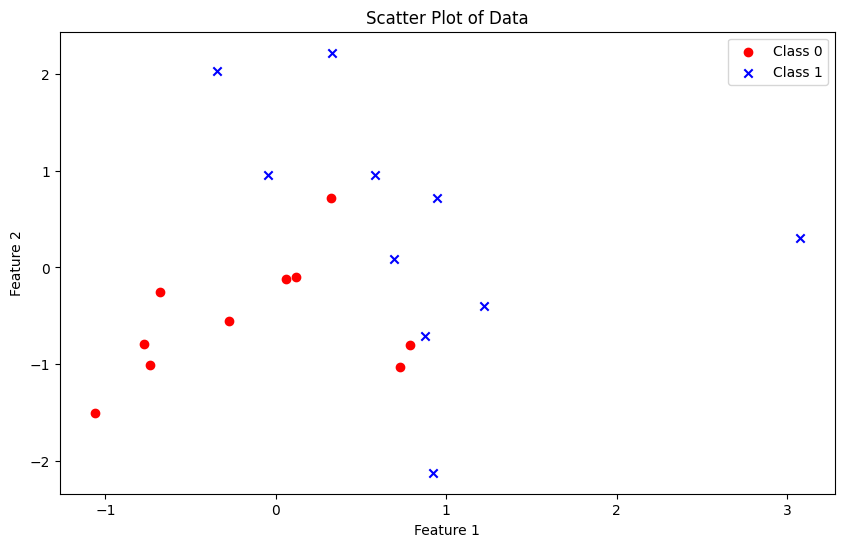

In [ ]:
#1
from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/ECE_460J/Lab3_P1.npz'
data = np.load(file_path)

X = data['X']
y = data['y']

plt.figure(figsize=(10, 6))
plt.scatter(X[y.flatten() == 0, 0], X[y.flatten() == 0, 1], c='red', marker='o', label='Class 0')
plt.scatter(X[y.flatten() == 1, 0], X[y.flatten() == 1, 1], c='blue', marker='x', label='Class 1')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Scatter Plot of Data')
plt.legend()


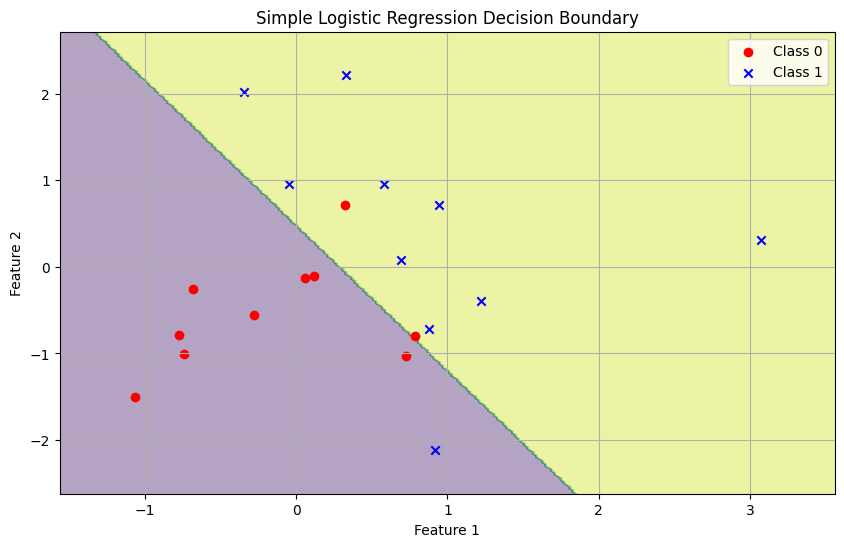

In [ ]:
#2
clf_simple = LogisticRegression()
clf_simple.fit(X, y.flatten())

x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),np.arange(y_min, y_max, 0.02))
Z = clf_simple.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.4)
plt.scatter(X[y.flatten() == 0, 0], X[y.flatten() == 0, 1], c='red', marker='o', label='Class 0')
plt.scatter(X[y.flatten() == 1, 0], X[y.flatten() == 1, 1], c='blue', marker='x', label='Class 1')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.title('Simple Logistic Regression Decision Boundary')
plt.grid(True)
plt.show()


In [ ]:
#3
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=4)
X_poly = poly.fit_transform(X)

features = X_poly.shape[1]
print(f'Number of features: {features}')
print(f"Original features: {X.shape[1]}")

Number of features: 15
Original features: 2


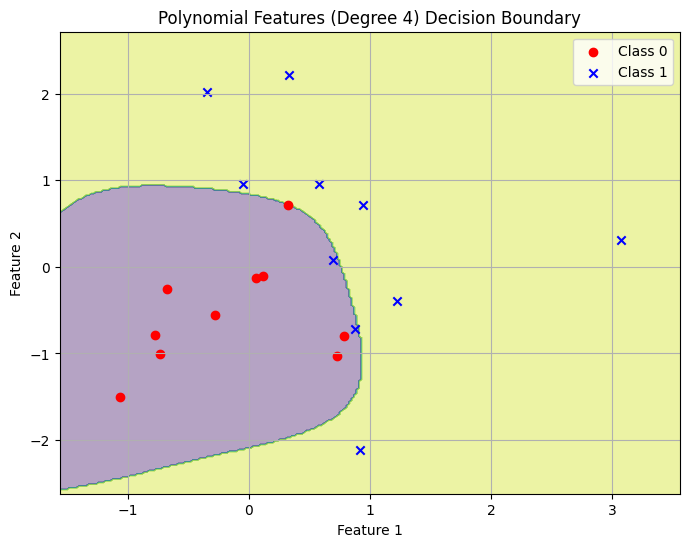

In [ ]:
clf_poly = LogisticRegression()
clf_poly.fit(X_poly, y.flatten())

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

mesh_points = np.c_[xx.ravel(), yy.ravel()]
mesh_poly = poly.transform(mesh_points)

Z_poly = clf_poly.predict(mesh_poly)
Z_poly = Z_poly.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z_poly, alpha=0.4)
plt.scatter(X[y.flatten() == 0, 0], X[y.flatten() == 0, 1], c='red', marker='o', label='Class 0')
plt.scatter(X[y.flatten() == 1, 0], X[y.flatten() == 1, 1], c='blue', marker='x', label='Class 1')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.title('Polynomial Features (Degree 4) Decision Boundary')
plt.grid(True)
plt.show()


# Problem 2

1. Load the data ``Lab3_P2.npz``. This is additional testing data for the previous problem.
2. Compute the training and testing error (fraction wrong) for the simple model and the extended (polynomial) model.
3. We learned about the log likelihood function and how its negative can be thought of as the loss function for logistic regression. This is called log_loss and you can import it from sklearn.metrics. Use that to compute the training and testing loss for the simple model and the extended model.
4. For the above problem, you cannot use ``model.predict()``. Figure out what (related) method you need to use, and explain how it is different from ``model.predict()``.

In [ ]:
from google.colab import drive
from sklearn.metrics import log_loss
from sklearn.preprocessing import PolynomialFeatures
drive.mount('/content/drive')

# Part 1
data = np.load('/content/drive/MyDrive/ECE_460J/Lab3_P2.npz')

# Part 2
train_X = X
train_Y = y

test_X = data['Xmore']
test_Y = data['ymore']

poly = PolynomialFeatures(degree=4)
train_X_poly = poly.fit_transform(train_X)
test_X_poly = poly.fit_transform(test_X)

simple_training_error = 1 - clf_simple.score(train_X, train_Y)
simple_testing_error = 1 - clf_simple.score(test_X, test_Y)
poly_training_error = 1 - clf_poly.score(train_X_poly, train_Y)
poly_testing_error = 1 - clf_poly.score(test_X_poly, test_Y)

print(f'Simple Model Training error: {simple_training_error}')
print(f'Simple Model Testing error: {simple_testing_error}\n')
print(f'Polynomial Model Training error: {poly_training_error}')
print(f'Polynomial Model Testing error: {poly_testing_error}\n')

# Part 3
simple_train_y_probabilities = clf_simple.predict_proba(train_X)
simple_test_y_probabilities = clf_simple.predict_proba(test_X)
poly_train_y_probabilities = clf_poly.predict_proba(train_X_poly)
poly_test_y_probabilities = clf_poly.predict_proba(test_X_poly)

simple_train_log_loss = log_loss(train_Y, simple_train_y_probabilities)
simple_test_log_loss = log_loss(test_Y, simple_test_y_probabilities)
poly_train_log_loss = log_loss(train_Y, poly_train_y_probabilities)
poly_test_log_loss = log_loss(test_Y, poly_test_y_probabilities)

print(f'Simple Model Training log loss: {simple_train_log_loss}')
print(f'Simple Model Testing log loss: {simple_test_log_loss}\n')
print(f'Polynomial Model Training log loss: {poly_train_log_loss}')
print(f'Polynomial Model Testing log loss: {poly_test_log_loss}')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Simple Model Training error: 0.15000000000000002
Simple Model Testing error: 0.26

Polynomial Model Training error: 0.09999999999999998
Polynomial Model Testing error: 0.36

Simple Model Training log loss: 0.4149091842063165
Simple Model Testing log loss: 0.5398704958052388

Polynomial Model Training log loss: 0.2453901369932452
Polynomial Model Testing log loss: 1.521796001855476


Part 4:<br>
Log loss needs the raw probabilities that the logistic regression model outputs (like 0.8 for 1, 0.2 for 0). The regular predict function just returns the highest probability (or some threshold) answer that the model outputs. The predict_proba returns the probability that the model predicts for each possible output, which log loss can use in its summation formula to compute the log loss.

# Problem 3

1. Load the data in ``Lab3_P3.npz``. How many training and testing data points do you have, and how many features?
2. Fit a logistic regression to the data. Do you think you are overfitting or underfitting? Explain and back up your answer with computations.
3. Use cross validation to find a good L2 regularizer. Try to find the best test accuracy.
4. Use cross validation to find a good L1 regularizer. Try to find the best test accuracy. **Note: If you try to run something like:
```
LogisticRegression(penalty='l1', C=1, max_iter=1000)
```
you will get a syntax error (which you will not get when you use similar code for L2 regularization). Read the documentation from sklearn to figure out how to fix this (hint: something to do with ``saga``...)

**Note: For CV, you may want to experiment with different valus of ``k``**.

In [ ]:
# Siyoung Kim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# Part 1: Load data
data3 = np.load('/content/drive/MyDrive/ECE_460J/Lab3_P3.npz')
# Check what's inside
print(data3.files)

X_train3 = data3['X_train']
y_train3 = data3['y_train'].flatten()
X_test3 = data3['X_test']
y_test3 = data3['y_test'].flatten()

print(f"Training data: {X_train3.shape[0]} points, {X_train3.shape[1]} features")
print(f"Testing data: {X_test3.shape[0]} points")

['X_train', 'X_test', 'y_train', 'y_test']
Training data: 35 points, 18 features
Testing data: 15 points


In [ ]:
# Part 2: Fit logistic regression and check overfitting/underfitting
from sklearn.linear_model import LogisticRegression

clf3 = LogisticRegression(max_iter=5000)
clf3.fit(X_train3, y_train3)

train_acc = clf3.score(X_train3, y_train3)
test_acc = clf3.score(X_test3, y_test3)

print(f"Training accuracy: {train_acc}")
print(f"Testing accuracy: {test_acc}")
print(f"Gap: {train_acc - test_acc}")

Training accuracy: 0.9714285714285714
Testing accuracy: 0.4666666666666667
Gap: 0.5047619047619047


The model is overfitting. Training accuracy is 97.1% while testing accuracy is only 46.7%, resulting in a gap of ~50%. This indicates the model fits the training data very well but fails to generalize to unseen data. This is likely due to having too many features relative to the number of training data points. Regularization (L1/L2) should help reduce this overfitting.

=== L2 Regularization ===
k=5: Best C=0.6158, CV accuracy=0.7429, Test accuracy=0.5333
k=10: Best C=0.6158, CV accuracy=0.7667, Test accuracy=0.5333
k=15: Best C=1.6238, CV accuracy=0.7556, Test accuracy=0.4667


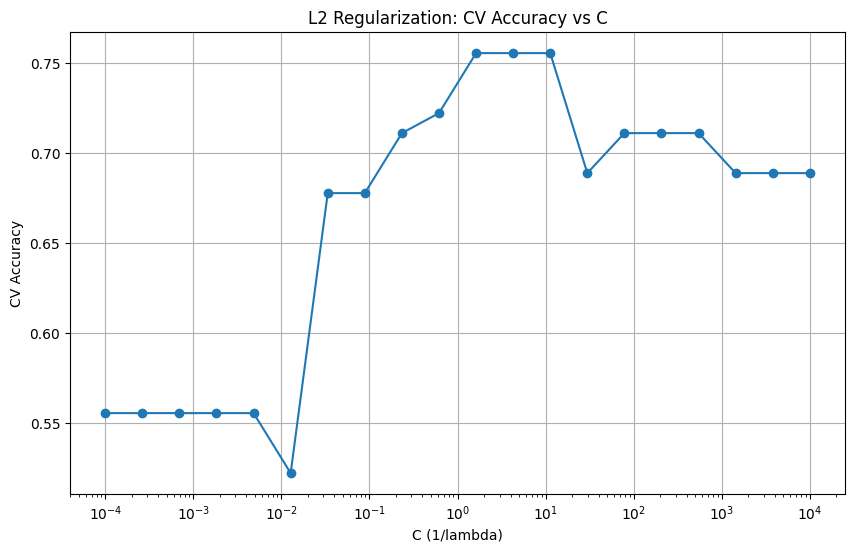

In [ ]:
# Part 3: Cross validation for L2 regularizer
from sklearn.model_selection import cross_val_score
import numpy as np

# Part 3: L2 regularization with cross validation
C_values = np.logspace(-4, 4, 20)
k_values = [5, 10, 15]

print("=== L2 Regularization ===")
for k in k_values:
    best_score = 0
    best_C = None
    cv_means = []

    for C in C_values:
        clf_l2 = LogisticRegression(penalty='l2', C=C, max_iter=5000)
        scores = cross_val_score(clf_l2, X_train3, y_train3, cv=k, scoring='accuracy')
        cv_means.append(scores.mean())
        if scores.mean() > best_score:
            best_score = scores.mean()
            best_C = C

    clf_l2_best = LogisticRegression(penalty='l2', C=best_C, max_iter=5000)
    clf_l2_best.fit(X_train3, y_train3)
    test_acc = clf_l2_best.score(X_test3, y_test3)

    print(f"k={k}: Best C={best_C:.4f}, CV accuracy={best_score:.4f}, Test accuracy={test_acc:.4f}")

# Plot for best k (optional)
plt.figure(figsize=(10, 6))
plt.semilogx(C_values, cv_means, 'o-')
plt.xlabel('C (1/lambda)')
plt.ylabel('CV Accuracy')
plt.title('L2 Regularization: CV Accuracy vs C')
plt.grid(True)
plt.show()

**L2 Regularisation Results**: The best test accuracy was 53.3%, achieved with k=5 (or k=10) and C=0.6158.This is an improvement over the unregularized model's test accuracy of 46.7%.The regularization helped reduce overfitting (training accuracy dropped from 97% but test accuracy improved), though the small dataset size limits performance.

=== L1 Regularization ===
k=5: Best C=11.2884, CV accuracy=0.7429, Test accuracy=0.4667
k=10: Best C=0.2336, CV accuracy=0.7250, Test accuracy=0.8667
k=15: Best C=1.6238, CV accuracy=0.7667, Test accuracy=0.6000


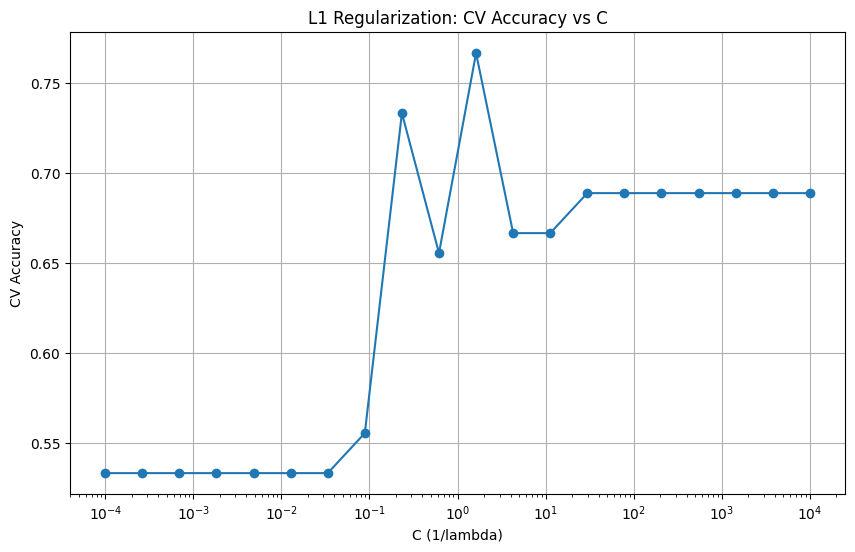

In [ ]:
# Part 4: L1 regularization with cross validation
print("=== L1 Regularization ===")
for k in k_values:
    best_score = 0
    best_C = None
    cv_means = []

    for C in C_values:
        clf_l1 = LogisticRegression(penalty='l1', C=C, solver='saga', max_iter=10000)
        scores = cross_val_score(clf_l1, X_train3, y_train3, cv=k, scoring='accuracy')
        cv_means.append(scores.mean())
        if scores.mean() > best_score:
            best_score = scores.mean()
            best_C = C

    clf_l1_best = LogisticRegression(penalty='l1', C=best_C, solver='saga', max_iter=10000)
    clf_l1_best.fit(X_train3, y_train3)
    test_acc = clf_l1_best.score(X_test3, y_test3)

    print(f"k={k}: Best C={best_C:.4f}, CV accuracy={best_score:.4f}, Test accuracy={test_acc:.4f}")

# Plot for best k
plt.figure(figsize=(10, 6))
plt.semilogx(C_values, cv_means, 'o-')
plt.xlabel('C (1/lambda)')
plt.ylabel('CV Accuracy')
plt.title('L1 Regularization: CV Accuracy vs C')
plt.grid(True)
plt.show()

**L1 Regularization Results:**
The best test accuracy was 86.7%, achieved with k=10 and C=0.2336.
This is a massive improvement over both the unregularized model (46.7%)
and the best L2 regularized model (53.3%).

L1 regularization performed better than L2 likely because it promotes sparsity.
It sets irrelevant feature coefficients to exactly zero, effectively performing
feature selection. With a small training set and many features, removing
unnecessary features helps the model generalize much better.

# Problem 4

In class we used random forests and bagging for CIFAR-10. Use similar techniques to get the best solution you can find for the MNIST dataset. This will require you to tune the parameters of Random Forests and Bagging. I recommend you use Random Forests from sklearn, and Boosting from XGBoost.

You will first need to load MNIST, using code that we saw in previous notebooks in this class.

In [ ]:
from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

#Loading MNIST
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X = mnist.data / 255.0
y = mnist.target.astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=10000, random_state=0, stratify=y)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])
print("Features:", X_train.shape[1])

#Random Forest:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=0,
    n_jobs=-1 #so that we use all core*Ç
)

rf.fit(X_train, y_train)

rf_train_acc = accuracy_score(y_train, rf.predict(X_train))
rf_test_acc = accuracy_score(y_test, rf.predict(X_test))

print("\nRandom Forest")
print("Train accuracy:", rf_train_acc)
print("Test accuracy:", rf_test_acc)

#XGBoost:

xgb = XGBClassifier(
    n_estimators=100, #used 300 at first but took ages
    max_depth=5,
    learning_rate=0.1,
    objective='multi:softmax',
    num_class=10,
    random_state=0
)

xgb.fit(X_train, y_train)

xgb_train_acc = accuracy_score(y_train, xgb.predict(X_train))
xgb_test_acc = accuracy_score(y_test, xgb.predict(X_test))

print("\nXGBoost")
print("Train accuracy:", xgb_train_acc)
print("Test accuracy:", xgb_test_acc)


#To compare them all:
print("\nFinal Comparison (Test Accuracy)")
print("----------------------------------")
print("Random Forest:", rf_test_acc)
print("XGBoost:", xgb_test_acc)

Training samples: 60000
Test samples: 10000
Features: 784

Random Forest
Train accuracy: 1.0
Test accuracy: 0.9727

XGBoost
Train accuracy: 0.9862833333333333
Test accuracy: 0.9645

Final Comparison (Test Accuracy)
----------------------------------
Random Forest: 0.9727
XGBoost: 0.9645


In this problem, we used ensemble methods to classify the MNIST dataset. Random Forests train many decision trees on bootstrapped samples and then combine their predictions, while XGBoost builds the trees sequentially, with each of them correcting the previous' errors. We tuned parameters like n_estimators, max_depth, and learning_rate to have the right balance between accuracy and runtime. Finally, we compare training and test accuracy to evaluate how well each model generalizes. Random Forests with 300 estimators, unlimited depth, and all cores achieved both a slightly higher accuracy and faster runtime than XGBoost with 100 estimators, max depth 5, learning rate 0.1, and using 10 classes. Nevertheless, both methods are quite accurate, with the random forest obtaining a 97.27% accuracy and XGBoost obtaining a 96.45%.

# Problem 5 (Optional)

Try to run logistic regression from sklearn for the MNIST data.

# Problem 6 (Optional)

The following is a logistic regression problem using a real data set, made available by the authors of the book ``Applied Regression and Muiltilevel Modeling'' by Gelman and Hill.

The point of this problem: besides gaining more experience and learning a few more things about logistic regression, my goal is to make clear that there are interesting/important datasets everywhere... and we should not shy away from finding them and using them!

Download the data from the book, which you can find here http://www.stat.columbia.edu/~gelman/arm/software/. In particular, we are interested in the **arsenic** data set. The file **wells.dat** contains data on 3,020 households in Bangladesh. For each family, the natural arsenic level of each well was measured. In addition, the distance to the nearest safest well was measured. Each family is also described by a feature that relates to their community involvement, and a feature that gives the education level of the head of household. We are interested in building a model that predicts whether the family decided to switch wells or not, based on being informed of the level of arsenic in the well. Thus the "label" for this problem is the binary vector that is the first column of the dataset, labeled "switch."

1. Fit a logistic regression model using only an offset term and the distance to the nearest safe well.
2. Plot your answer: that is, plot the probability of switching wells as a function of the distance to the nearest safe well.
3. Interpreting logistic regression coefficients: In linear regression, there is an obvious interpretation for the coefficients of linear regression (e.g., $\beta_{sf}$ is the additional value of a house per additional square foot). This is not so clear in logistic regression because of the non-linearity of the soft-max function. One way to interpret a particular coefficient is using the "rule-of-4". This can be derived by simple calculus. It says: for any coefficient $w_i$ of the logistic regression, $w_i/4$ is the *maximum possible effect* on the probability our model predicts "1" that can result from a change in $x_i$ by 1 unit. We can use it here, for example, with analyzing the maximum possible change in the probability of changing wells, correlated with an additional 100 meters of distance.
4. Now solve a logistic regression incorporating the constant term, the distance and also arsenic levels. Report the coefficients
5. Next we want to answer the question of which factor is more significant, distance, or arsenic levels? This is not a well specified question, since these two features have different units. One natural choice is to ask if after normalizing by the respective standard deviations of each feature, if moving one unit in one (normalized) feature predicts a larger change in probability of switching wells, than moving one unit in the other (also normalized) feature. Use this reasoning to answer the question.
6. Now consider all the features in the data set. Also consider adding interaction terms among all features that have a large main effect. Use cross validation to build the best model you can (using your training set only), and then report the test error of your best model. (Note that since you have essentially unlimited access to your test set, this opens the door for massive overfitting. In contrast, Kaggle competitions try to mollify this by giving you only limited access to the test set.)
7. (Optional) Now also play around with $\ell_1$ and $\ell_2$ regularization, and try to build the most accurate model you can (accuracy computed on the test data).